### Initialisation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, precision_recall_curve, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../outputs/data/train_data.csv')

### Data Preparation

In [2]:
# Select features (same as Random Forest for fair comparison)
key_features = [
    'EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SOURCE_1',
    'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO',
    'DAYS_EMPLOYED_YEARS', 'DAYS_BIRTH_YEARS',
    'AMT_CREDIT', 'AMT_INCOME_TOTAL',
    'CNT_FAM_MEMBERS',
    'EMPLOYMENT_TO_AGE_RATIO',
]

# Add other numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
additional_cols = [c for c in numeric_cols if c not in key_features + ['TARGET', 'SK_ID_CURR']]
key_features.extend(additional_cols[:30])

# Create feature matrix
X = df[key_features].copy()
y = df['TARGET'].copy()

print(f"\nUsing {X.shape[1]} features")
print(f"Total samples: {X.shape[0]:,}")
print(f"Default rate: {y.mean():.2%}")

# Handle missing values
for col in X.columns:
    if X[col].dtype in ['float64', 'int64']:
        X[col] = X[col].fillna(X[col].median())
    else:
        X[col] = X[col].fillna(X[col].mode()[0] if len(X[col].mode()) > 0 else 0)



Using 41 features
Total samples: 307,511
Default rate: 8.07%


### Train-Test Split

In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"\nTraining: {X_train.shape[0]:,} samples")
print(f"Validation: {X_val.shape[0]:,} samples")
print(f"Default rate in training: {y_train.mean():.2%}")

# Calculate scale_pos_weight for class imbalance
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")


Training: 246,008 samples
Validation: 61,503 samples
Default rate in training: 8.07%
scale_pos_weight: 11.39


### XGBoost with Hyperparameter Tuning

In [4]:
import xgboost as xgb

# Base XGBoost model
xgb_base = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc'
)

# Hyperparameter grid for RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [4, 6, 8, 10, 12],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'reg_alpha': [0, 0.1, 0.5, 1.0],  # L1 regularization
    'reg_lambda': [0.5, 1.0, 1.5, 2.0],  # L2 regularization
}

In [5]:
print("Searching hyperparameters (5-10 minutes)...")

random_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist,
    n_iter=30,  # Try 30 random combinations
    scoring='roc_auc',
    cv=3,  # 3-fold cross-validation
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print(f"\nBest ROC-AUC from CV: {random_search.best_score_:.4f}")
print(f"Best parameters: {random_search.best_params_}")

# Train final model with best parameters
best_xgb = random_search.best_estimator_

Searching hyperparameters (5-10 minutes)...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best ROC-AUC from CV: 0.7471
Best parameters: {'subsample': 0.9, 'reg_lambda': 1.5, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.9}


### Evaluation

In [6]:
y_pred_proba = best_xgb.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred_proba)

print(f"\n{'='*50}")
print(f"XGBOOST RESULTS")
print(f"{'='*50}")
print(f"ROC-AUC: {auc:.4f}")

# Compare with Random Forest baseline
print(f"\nComparison:")
print(f"  Random Forest baseline: 0.701")
print(f"  Improved Random Forest: 0.737")
print(f"  XGBoost:                {auc:.4f}")
if auc > 0.737:
    print(f"   XGBoost improvement: +{(auc - 0.737)*100:.1f} percentage points")
else:
    print(f"   XGBoost did not improve. Try adjusting parameters.")


XGBOOST RESULTS
ROC-AUC: 0.7527

Comparison:
  Random Forest baseline: 0.701
  Improved Random Forest: 0.737
  XGBoost:                0.7527
   XGBoost improvement: +1.6 percentage points


### Find Optimal Threshold

In [7]:
precisions, recalls, thresholds = precision_recall_curve(y_val, y_pred_proba)

# Find threshold that captures 80% of defaults
target_recall = 0.80
closest_idx = (np.abs(recalls - target_recall)).argmin()
business_threshold = thresholds[closest_idx] if closest_idx < len(thresholds) else 0.5

# Find threshold that maximizes F1 score (balanced)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_f1_idx = np.argmax(f1_scores)
f1_threshold = thresholds[best_f1_idx] if best_f1_idx < len(thresholds) else 0.5

print(f"Threshold to capture 80% of defaults: {business_threshold:.3f}")
print(f"Threshold for best F1 score: {f1_threshold:.3f} (F1 = {f1_scores[best_f1_idx]:.3f})")

# Apply both thresholds
y_pred_business = (y_pred_proba > business_threshold).astype(int)
y_pred_f1 = (y_pred_proba > f1_threshold).astype(int)

Threshold to capture 80% of defaults: 0.401
Threshold for best F1 score: 0.660 (F1 = 0.307)


### Confusion Matrix and Business Metrics

In [8]:
tn, fp, fn, tp = confusion_matrix(y_val, y_pred_business).ravel()

print(f"  True Positives (correctly identified defaults): {tp:,}")
print(f"  False Positives (incorrectly flagged as risky): {fp:,}")
print(f"  False Negatives (missed defaults): {fn:,}")
print(f"  True Negatives (correctly approved): {tn:,}")

precision_business = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_business = tp / (tp + fn) if (tp + fn) > 0 else 0

print(f"\n  Precision: {precision_business:.2%} (of flagged, this many actually default)")
print(f"  Recall: {recall_business:.2%} (of defaults, this many caught)")

  True Positives (correctly identified defaults): 3,972
  False Positives (incorrectly flagged as risky): 25,316
  False Negatives (missed defaults): 993
  True Negatives (correctly approved): 31,222

  Precision: 13.56% (of flagged, this many actually default)
  Recall: 80.00% (of defaults, this many caught)


### Feature Importance

In [9]:
feature_importance_xgb = pd.DataFrame({
    'feature': X.columns,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features (by gain):")
for i, row in feature_importance_xgb.head(10).iterrows():
    print(f"  {i+1}. {row['feature']}: {row['importance']:.4f}")


Top 10 Most Important Features (by gain):
  1. EXT_SOURCE_2: 0.1525
  2. EXT_SOURCE_3: 0.1454
  3. EXT_SOURCE_1: 0.0487
  6. DAYS_EMPLOYED_YEARS: 0.0415
  22. FLAG_EMP_PHONE: 0.0345
  34. REG_CITY_NOT_WORK_CITY: 0.0311
  14. AMT_GOODS_PRICE: 0.0288
  33. REG_CITY_NOT_LIVE_CITY: 0.0275
  20. OWN_CAR_AGE: 0.0274
  28. REGION_RATING_CLIENT_W_CITY: 0.0265


### SHAP Interpretability

> SHAP summary plot saved to outputs/figures/shap_summary_plot.png
> SHAP bar plot saved to outputs/figures/shap_bar_plot.png

Top 5 Features by SHAP importance (most impactful on predictions):
  EXT_SOURCE_3: 0.3775
  EXT_SOURCE_2: 0.3621
  AMT_GOODS_PRICE: 0.2725
  EXT_SOURCE_1: 0.1837
  AMT_CREDIT: 0.1655


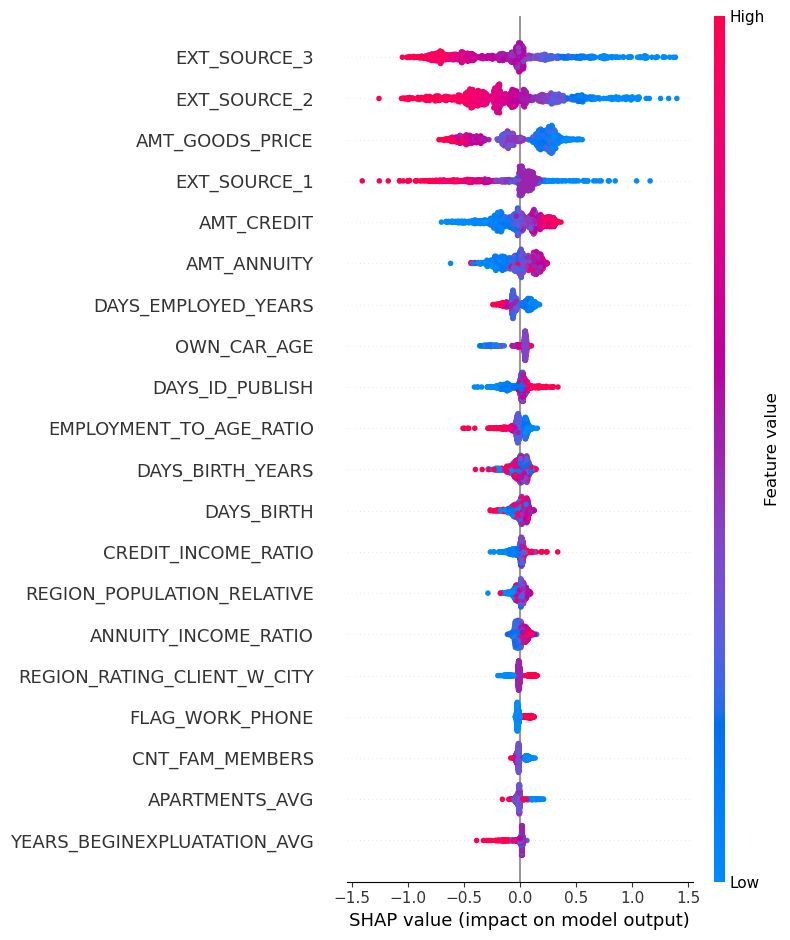

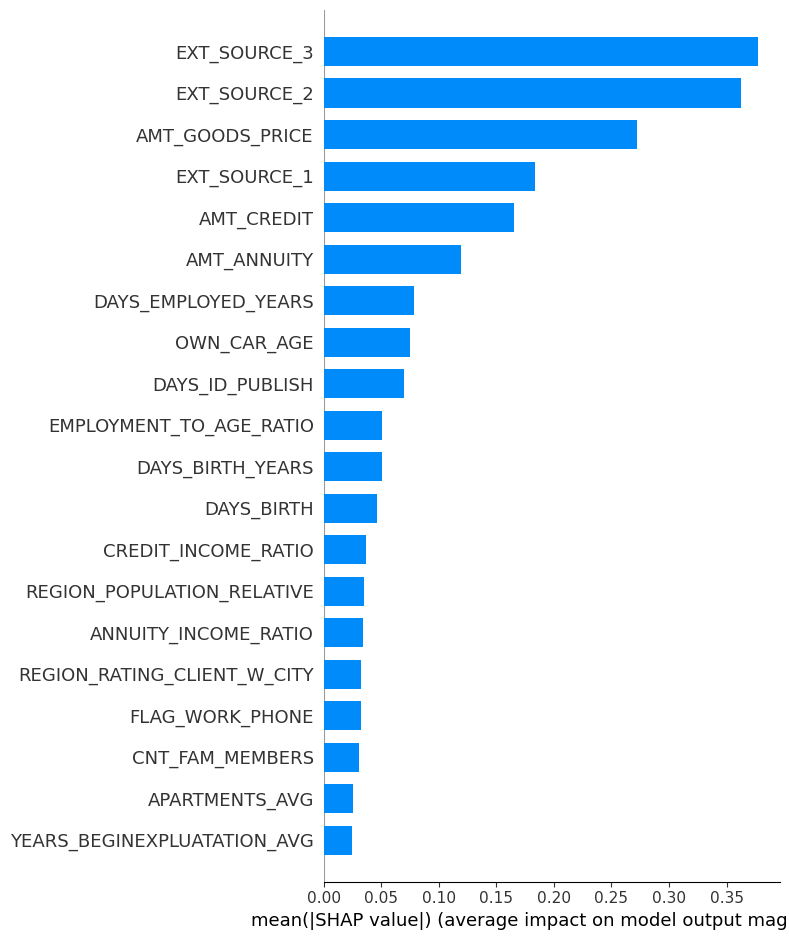

In [10]:
import shap

# Use a smaller sample for SHAP (full dataset is large)
shap_sample_size = min(1000, X_val.shape[0])
X_shap_sample = X_val.sample(n=shap_sample_size, random_state=42)

# Create TreeExplainer
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_shap_sample)

# Summary plot (saved to file)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap_sample, show=False)
plt.tight_layout()
plt.savefig('../outputs/figures/shap_summary_plot.png', dpi=150, bbox_inches='tight')
print("> SHAP summary plot saved to outputs/figures/shap_summary_plot.png")

# Top features bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap_sample, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig('../outputs/figures/shap_bar_plot.png', dpi=150, bbox_inches='tight')
print("> SHAP bar plot saved to outputs/figures/shap_bar_plot.png")

# Feature importance comparison (XGBoost vs SHAP)
shap_importance = np.abs(shap_values).mean(axis=0)
shap_importance_df = pd.DataFrame({
    'feature': X_shap_sample.columns,
    'shap_importance': shap_importance
}).sort_values('shap_importance', ascending=False)

print("\nTop 5 Features by SHAP importance (most impactful on predictions):")
for i, row in shap_importance_df.head(5).iterrows():
    print(f"  {row['feature']}: {row['shap_importance']:.4f}")
    

### Save Results

In [11]:
import joblib

# Save XGBoost model
joblib.dump(best_xgb, '../outputs/models/xgboost_model.pkl')
print("> XGBoost model saved to outputs/models/xgboost_model.pkl")

# Save feature importance
feature_importance_xgb.to_csv('../outputs/results/xgboost_feature_importance.csv', index=False)
print("> XGBoost feature importance saved")

# Save predictions for dashboard
predictions_df = X_val.copy()
predictions_df['actual_default'] = y_val
predictions_df['default_probability'] = y_pred_proba
predictions_df['risk_flag'] = y_pred_business
predictions_df.to_csv('../outputs/results/xgboost_predictions.csv', index=False)
print("> Predictions saved to outputs/results/xgboost_predictions.csv")

# Save business summary
business_summary = {
    'model': 'XGBoost',
    'roc_auc': auc,
    'optimal_recall_threshold': business_threshold,
    'precision_at_threshold': precision_business,
    'recall_at_threshold': recall_business,
    'top_feature': feature_importance_xgb.iloc[0]['feature'],
    'second_feature': feature_importance_xgb.iloc[1]['feature'] if len(feature_importance_xgb) > 1 else 'N/A',
    'third_feature': feature_importance_xgb.iloc[2]['feature'] if len(feature_importance_xgb) > 2 else 'N/A',
}

summary_df = pd.DataFrame([business_summary])
summary_df.to_csv('../outputs/results/xgboost_business_summary.csv', index=False)
print("> Business summary saved")

> XGBoost model saved to outputs/models/xgboost_model.pkl
> XGBoost feature importance saved
> Predictions saved to outputs/results/xgboost_predictions.csv
> Business summary saved


### Final Summary

In [12]:
print("\n" + "=" * 60)
print("FINAL METRICS FOR CONSULTING SUMMARY")
print("=" * 60)

print(f"""
┌─────────────────────────────────────────────────────────────┐
│                 XGBOOST MODEL PERFORMANCE                   │
├─────────────────────────────────────────────────────────────┤
│  ROC-AUC:                         {auc:.4f}                    │
│                                                             │
│  Improvement over Random Forest:  +{(auc - 0.737)*100:.1f}%                     │
├─────────────────────────────────────────────────────────────┤
│                    BUSINESS METRICS                         │
├─────────────────────────────────────────────────────────────┤
│  At {business_threshold:.2f} threshold (80% recall target):                     │
│    Precision:                    {precision_business:.1%}                      │
│    Recall:                       {recall_business:.1%}                      │
├─────────────────────────────────────────────────────────────┤
│                    TOP PREDICTORS                           │
├─────────────────────────────────────────────────────────────┤
│  #1: {feature_importance_xgb.iloc[0]['feature'][:30]}                                           │
│  #2: {feature_importance_xgb.iloc[1]['feature'][:30] if len(feature_importance_xgb) > 1 else 'N/A'}                                           │
│  #3: {feature_importance_xgb.iloc[2]['feature'][:30] if len(feature_importance_xgb) > 2 else 'N/A'}                                           │
└─────────────────────────────────────────────────────────────┘
""")



FINAL METRICS FOR CONSULTING SUMMARY

┌─────────────────────────────────────────────────────────────┐
│                 XGBOOST MODEL PERFORMANCE                   │
├─────────────────────────────────────────────────────────────┤
│  ROC-AUC:                         0.7527                    │
│                                                             │
│  Improvement over Random Forest:  +1.6%                     │
├─────────────────────────────────────────────────────────────┤
│                    BUSINESS METRICS                         │
├─────────────────────────────────────────────────────────────┤
│  At 0.40 threshold (80% recall target):                     │
│    Precision:                    13.6%                      │
│    Recall:                       80.0%                      │
├─────────────────────────────────────────────────────────────┤
│                    TOP PREDICTORS                           │
├─────────────────────────────────────────────────────────────┤
│